In [3]:
#TITANIC
#IMPORTING REQUIRED LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [4]:
#PART1
#Loading the csv data into a pandas dataframe
titanic_data = pd.read_csv(r'C:\Users\USER\Desktop\TLK\Titanic-Dataset.csv')

In [5]:
titanic_data.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [6]:
titanic_data.shape

(891, 12)

In [7]:
titanic_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
titanic_data.isnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


In [9]:
#Check for missing values
titanic_data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [10]:
#Check for duplicates
titanic_data.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
886    False
887    False
888    False
889    False
890    False
Length: 891, dtype: bool

In [11]:
titanic_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [12]:
titanic_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [13]:
#PART2
#DATA PREPROCESSING

In [14]:
#Missing Value Treatment

In [15]:
titanic_data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [16]:
#Drop Cabin column as the missing values is above 70% of the entire rows
titanic_data = titanic_data.drop(columns = 'Cabin', axis=1)

In [17]:
#Replace the missing values in the age columnn with the mean vallue of the age
titanic_data['Age'] = titanic_data['Age'].fillna(titanic_data['Age'].median()) 

In [18]:
#Replace the missing values in the Embarked columnn with the mode vallue of the age
titanic_data['Embarked'] = titanic_data['Embarked'].fillna(titanic_data['Embarked'].mode()[0])

In [19]:
titanic_data.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

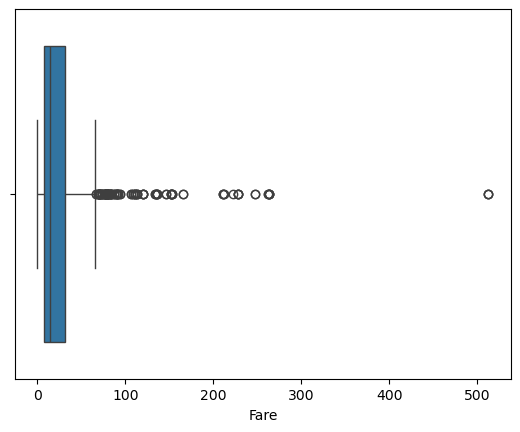

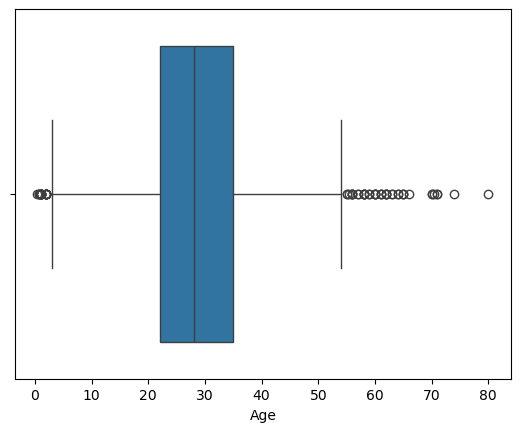

In [20]:
#PART C outlier detection and treatment
#Boxplot
sns.boxplot(x=titanic_data['Fare'])
plt.show()

sns.boxplot(x=titanic_data['Age'])
plt.show()

In [21]:
Q1 = titanic_data['Fare'].quantile(0.25)
Q3 = titanic_data['Fare'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = titanic_data[(titanic_data['Fare'] < lower_bound) | (titanic_data['Fare'] > upper_bound)]
print(f"Number of outliers in Fare: {len(outliers)}")

Number of outliers in Fare: 116


In [22]:
Q1 = titanic_data['Fare'].quantile(0.25)
Q3 = titanic_data['Fare'].quantile(0.75)
Q1, Q3

(np.float64(7.9104), np.float64(31.0))

In [23]:
IQR = Q3 - Q1
IQR

np.float64(23.0896)

In [24]:
lower_limit = Q1 - 1.5*IQR
upper_limit = Q3 + 1.5*IQR
lower_limit, upper_limit

(np.float64(-26.724), np.float64(65.6344))

In [25]:
#Display the outliers
titanic_data['Fare'][(titanic_data['Fare'] < lower_limit)|(titanic_data['Fare'] > upper_limit)]

1       71.2833
27     263.0000
31     146.5208
34      82.1708
52      76.7292
         ...   
846     69.5500
849     89.1042
856    164.8667
863     69.5500
879     83.1583
Name: Fare, Length: 116, dtype: float64

In [26]:
#ROW REMOVAL METHOD
titanic_data_no_outlier = titanic_data['Fare'][(titanic_data['Fare'] > lower_limit)&(titanic_data['Fare'] < upper_limit)]

In [27]:
titanic_data_no_outlier

0       7.2500
2       7.9250
3      53.1000
4       8.0500
5       8.4583
        ...   
886    13.0000
887    30.0000
888    23.4500
889    30.0000
890     7.7500
Name: Fare, Length: 775, dtype: float64

In [28]:
#CAP/REPLACEMENT METHOD
titanic_data['Fare'] = titanic_data['Fare'].clip(lower_limit, upper_limit)

In [29]:
titanic_data['Fare']

0       7.2500
1      65.6344
2       7.9250
3      53.1000
4       8.0500
        ...   
886    13.0000
887    30.0000
888    23.4500
889    30.0000
890     7.7500
Name: Fare, Length: 891, dtype: float64

In [30]:
#Categorical Encodiing

In [31]:
#LABEL ENCODING
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
titanic_data['Sex'] = le.fit_transform(titanic_data['Sex']) #female is 0, male is 1(Alphabetically)

In [32]:
titanic_data['Sex']

0      1
1      0
2      0
3      0
4      1
      ..
886    1
887    0
888    0
889    1
890    1
Name: Sex, Length: 891, dtype: int64

In [33]:
#ONE HOT ENCODING
titanic_data = pd.get_dummies(titanic_data, columns=['Embarked'], drop_first=True)

In [34]:
titanic_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,65.6344,False,False
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,False,True
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",1,27.0,0,0,211536,13.0000,False,True
887,888,1,1,"Graham, Miss. Margaret Edith",0,19.0,0,0,112053,30.0000,False,True
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",0,28.0,1,2,W./C. 6607,23.4500,False,True
889,890,1,1,"Behr, Mr. Karl Howell",1,26.0,0,0,111369,30.0000,False,False


In [35]:
#FEATURE SCALING
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
titanic_data[['Age', 'Fare']] = scaler.fit_transform(titanic_data[['Age', 'Fare']])

In [36]:
#PART 3
#EXPLORATORY DATA ANALYSIS

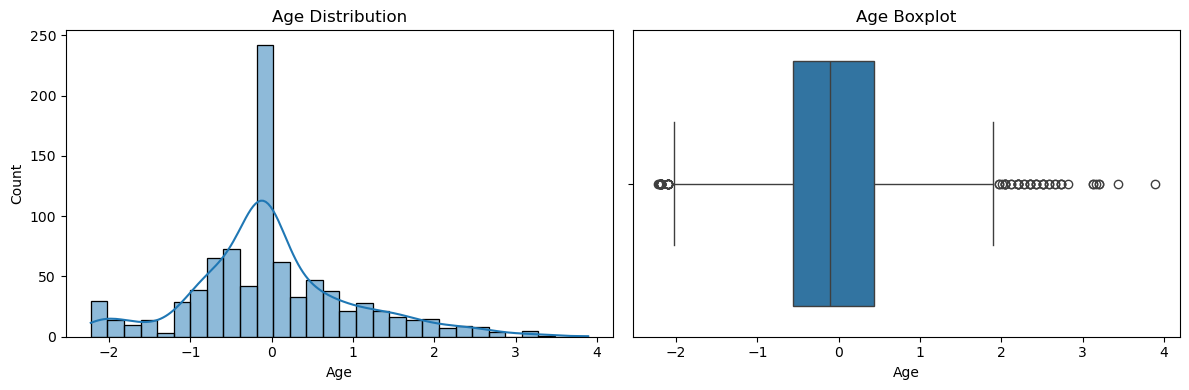

count    8.910000e+02
mean     2.272780e-16
std      1.000562e+00
min     -2.224156e+00
25%     -5.657365e-01
50%     -1.046374e-01
75%      4.333115e-01
max      3.891554e+00
Name: Age, dtype: float64
----------------------------------------


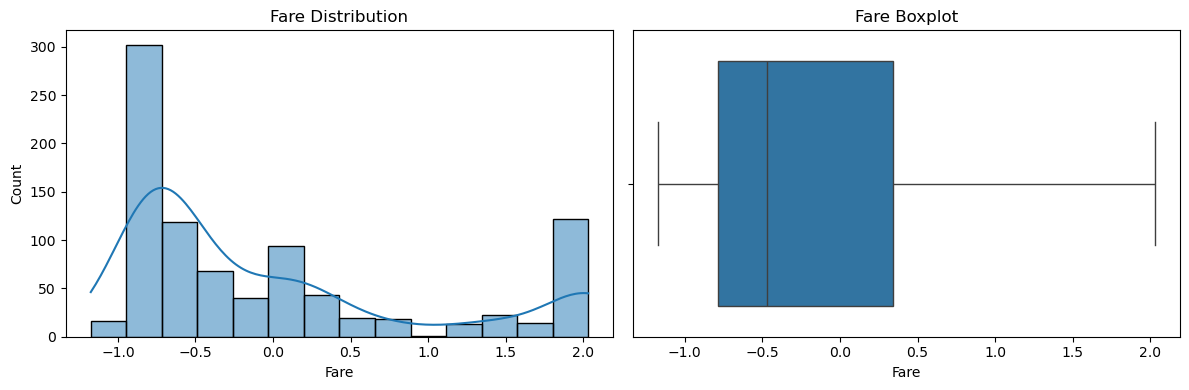

count    8.910000e+02
mean     9.968332e-17
std      1.000562e+00
min     -1.174727e+00
25%     -7.882908e-01
50%     -4.686152e-01
75%      3.396748e-01
max      2.031623e+00
Name: Fare, dtype: float64
----------------------------------------


In [37]:
numeric_cols = ['Age', 'Fare']

for col in numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
   #BOXPLOT AND HISTOGRAM FOR NUMERICAL FEATURES
  
    # Histogram - shows distribution shape
    sns.histplot(titanic_data[col], kde=True, ax=axes[0])
    axes[0].set_title(f'{col} Distribution')

     # Boxplot - shows spread and outliers
    sns.boxplot(x=titanic_data[col], ax=axes[1])
    axes[1].set_title(f'{col} Boxplot')
    
    plt.tight_layout()
    plt.show()
    
    print(titanic_data[col].describe())
    print('-'*40)

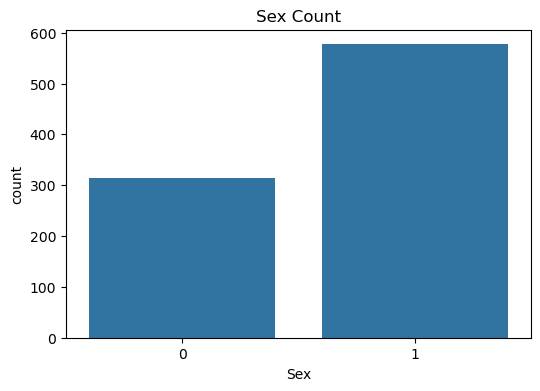

Sex
1    0.647587
0    0.352413
Name: proportion, dtype: float64
----------------------------------------


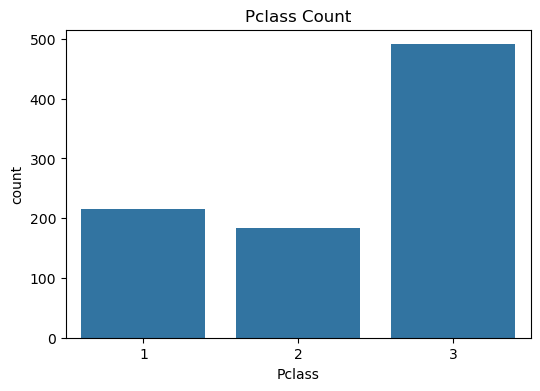

Pclass
3    0.551066
1    0.242424
2    0.206510
Name: proportion, dtype: float64
----------------------------------------


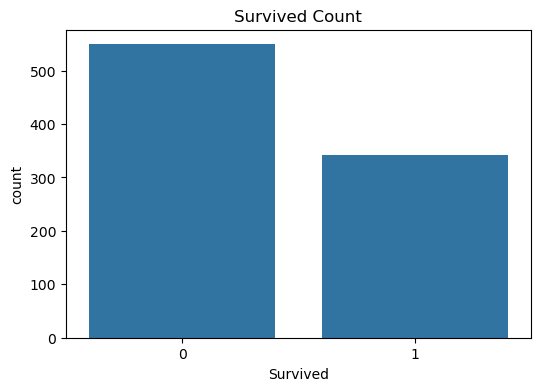

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64
----------------------------------------


In [38]:
categorical_cols = ['Sex', 'Pclass', 'Survived']
 #COUNT FOR CATEGORICAL COLUMNS
for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=col, data=titanic_data)
    plt.title(f'{col} Count')
    plt.show()
    
    print(titanic_data[col].value_counts(normalize=True))  # shows proportions
    print('-'*40)

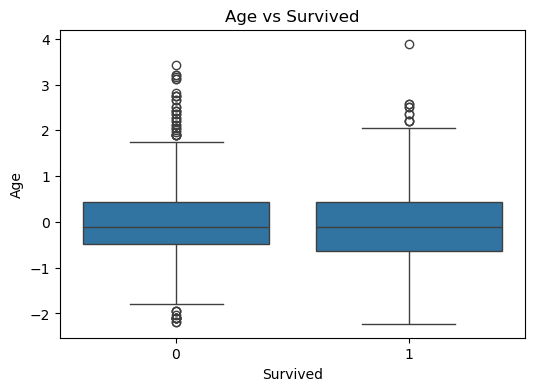

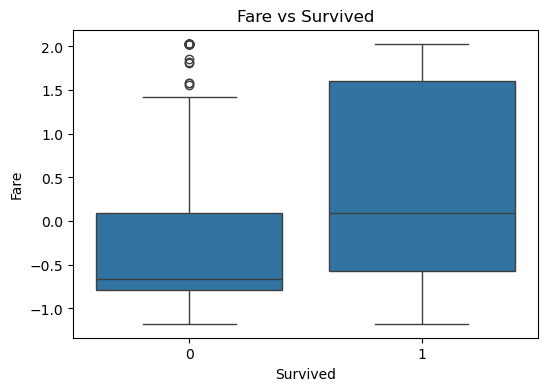

In [39]:
for col in ['Age', 'Fare']:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Survived', y=col, data=titanic_data)
    plt.title(f'{col} vs Survived')
    plt.show()

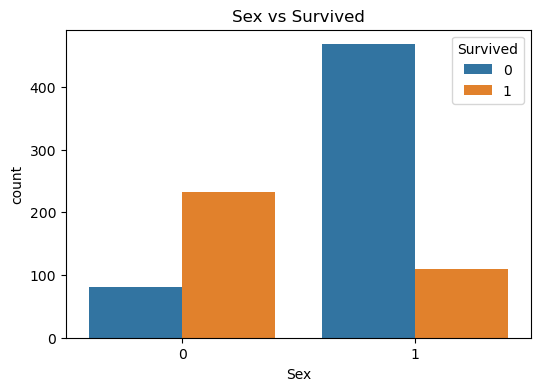

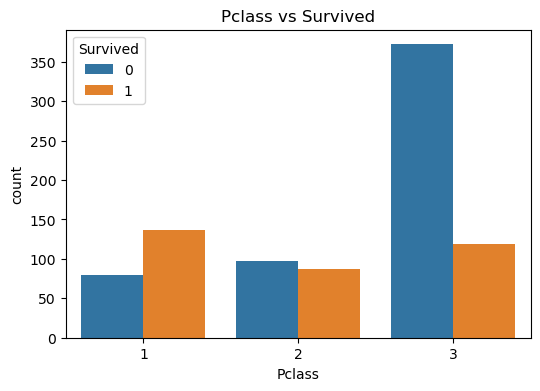

In [40]:
for col in ['Sex', 'Pclass',]:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue='Survived', data=titanic_data)
    plt.title(f'{col} vs Survived')
    plt.show()

In [43]:
numeric_cols = ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S']
corr = titanic_data[numeric_cols].corr()
print(corr)

            Survived    Pclass       Sex       Age     SibSp     Parch  \
Survived    1.000000 -0.338481 -0.543351 -0.064910 -0.035322  0.081629   
Pclass     -0.338481  1.000000  0.131900 -0.339898  0.083081  0.018443   
Sex        -0.543351  0.131900  1.000000  0.081163 -0.114631 -0.245489   
Age        -0.064910 -0.339898  0.081163  1.000000 -0.233296 -0.172482   
SibSp      -0.035322  0.083081 -0.114631 -0.233296  1.000000  0.414838   
Parch       0.081629  0.018443 -0.245489 -0.172482  0.414838  1.000000   
Fare        0.317430 -0.715300 -0.234969  0.144204  0.332021  0.292616   
Embarked_Q  0.003650  0.221009 -0.074115 -0.031415 -0.026354 -0.081228   
Embarked_S -0.149683  0.074053  0.119224 -0.006729  0.068734  0.060814   

                Fare  Embarked_Q  Embarked_S  
Survived    0.317430    0.003650   -0.149683  
Pclass     -0.715300    0.221009    0.074053  
Sex        -0.234969   -0.074115    0.119224  
Age         0.144204   -0.031415   -0.006729  
SibSp       0.332021   -

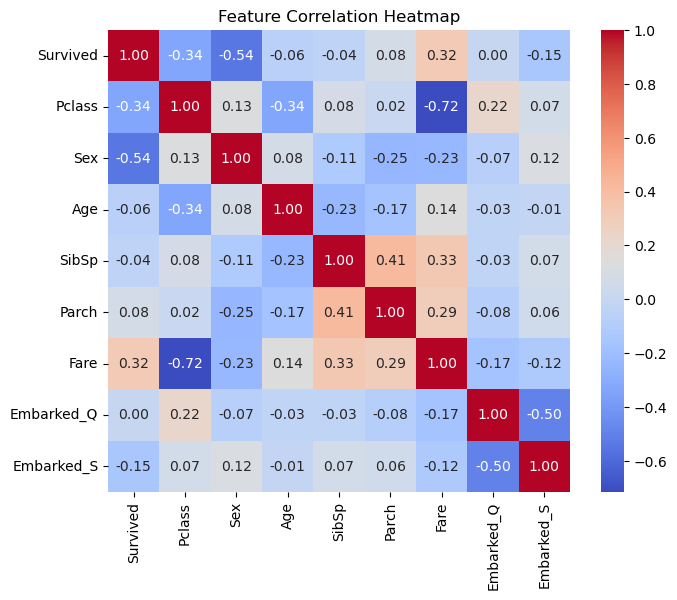

In [44]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Feature Correlation Heatmap')
plt.show()

In [45]:
print(corr['Survived'].sort_values(ascending=False))

Survived      1.000000
Fare          0.317430
Parch         0.081629
Embarked_Q    0.003650
SibSp        -0.035322
Age          -0.064910
Embarked_S   -0.149683
Pclass       -0.338481
Sex          -0.543351
Name: Survived, dtype: float64


In [46]:
titanic_data.to_csv('TITANIC_CLEANED.csv', index=False)